# Sales Potential Segmentation of Seasonal Customers Using Clustering

This project analyzes the sales potential of seasonal customers such as retail stores, bars, and restaurants.

The objective of the analysis is to identify groups of customers with similar characteristics based on traffic levels, refrigeration capacity,
location characteristics, and historical sales performance.

Using clustering techniques, customers are segmented into four business categories:

Gold  
Silver  
Bronze  
Iron  

These segments represent different levels of sales potential and help businesses prioritize investments, equipment allocation, and sales strategies.

## Research Question

How can clustering algorithms be used to segment seasonal customers such as stores, bars, and restaurants based on traffic levels,
refrigeration capacity, and historical sales in order to identify customers with the highest sales potential?

## Project Objectives

The main objectives of this project are:

- To explore the dataset and understand customer characteristics
- To analyze the relationship between traffic, refrigeration capacity, and sales
- To preprocess the dataset for clustering analysis
- To apply clustering algorithms to group customers with similar characteristics
- To classify customers into four sales potential segments: Gold, Silver, Bronze, and Iron
- To interpret the results from a business perspective

## Dataset Description

The dataset contains information about seasonal customers such as retail stores, bars, and restaurants.

Each row represents a customer outlet and includes attributes describing the environment, equipment availability, and sales performance.

The dataset contains the following variables:

Customer – Unique identifier of the outlet

City – Name of the city where the outlet operates

Channel – Type of customer channel (Hotels, QSR, etc.)

Segment – Existing traffic-based classification

Urbanicity – Level of urbanization of the area

Traffic – Estimated number of people passing near the outlet

Traffic Index – Category of traffic intensity

Equipment (Y/N) – Indicates whether a refrigerator is installed at the outlet

\# of doors – Number of refrigerator doors installed at the outlet

Sales 2025 CS – Sales volume generated by the customer

Refrigeration capacity, measured by the number of refrigerator doors, is an important operational factor that influences the ability of 
a customer to sell cold beverages during the summer season.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

from sklearn.linear_model import LinearRegression

from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

pandas – for loading, cleaning, and exploring the dataset.

numpy – for numerical operations and array computations.

matplotlib / seaborn – for visualizing distributions, correlations, and clusters.

StandardScaler (sklearn) – to scale numeric features for clustering.

KMeans (sklearn) – to segment customers into clusters based on features.

hierarchy (scipy) – to perform and visualize hierarchical clustering.

silhouette_score (sklearn) – to evaluate clustering quality.

Axes3D (mpl_toolkits.mplot3d) – to create 3D plots of clusters.

### Libraries and References
- **pandas** – data loading, cleaning, exploration ([docs](https://pandas.pydata.org/docs/))
- **numpy** – numerical operations ([docs](https://numpy.org/doc/stable/))
- **matplotlib / seaborn** – data visualization ([Matplotlib docs](https://matplotlib.org/stable/contents.html), [Seaborn docs](https://seaborn.pydata.org/))
- **scikit-learn** – scaling & clustering ([docs](https://scikit-learn.org/stable/))
- **scipy.cluster.hierarchy** – hierarchical clustering ([docs](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html))

### Load Dataset

In [2]:
df = pd.read_csv("Segmentation_Summer Seasonal.dat", sep="\t", encoding="cp1251")

df.head()

,Customer,City,Channel,Segment,Urbanicity,Traffic,Traffic Index,Equipment (Y/N),# of doors,Sales 2025 CS
0,10000,ЗЛАТНИ ПЯСЪЦИ,Hotels,Seasonal High Traffic,3,"30422,86",High,Yes,6,0
1,10001,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"58764,25",High,Yes,0,0
2,10002,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"32763,5",High,Yes,0,0
3,10003,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal Low/Mid Traffic,1,"23147,5",Medium,Yes,0,0
4,10004,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"34339,25",High,Yes,2,56


## Data Cleaning

Some numeric values contain commas as decimal separators. These values need to be converted into numeric format for analysis.

The Equipment column is also converted into numeric values.

### Data Cleaning Code

In [3]:
# Fix decimal separator in Traffic
df["Traffic"] = df["Traffic"].astype(str).str.replace(",", ".").astype(float)

# Convert equipment column to numeric
df["Equipment (Y/N)"] = df["Equipment (Y/N)"].map({
    "Yes":1,
    "No":0
})

# Convert "# of doors" to float
df["# of doors"] = df["# of doors"].astype(str).str.replace(",", ".").astype(float)

# Convert "Sales 2025 CS" to float
df["Sales 2025 CS"] = df["Sales 2025 CS"].astype(str).str.replace(",", ".").astype(float)

### Missing Values Check

Before continuing the analysis, we verify whether the dataset contains missing values.
If the result is 0 the values are correct.

In [4]:
df.isnull().sum()

Customer           0
City               0
Channel            0
Segment            0
Urbanicity         0
Traffic            0
Traffic Index      0
Equipment (Y/N)    0
# of doors         0
Sales 2025 CS      0
dtype: int64

## Exploratory Data Analysis

Before applying clustering algorithms, we explore the dataset to understand the distribution of key variables such as traffic,
refrigeration capacity, and sales.

### Dataset Structure

We use `df.info()` to quickly inspect the dataset structure, including number of rows and columns, data types, and missing values. `df.describe()` provides summary statistics for numeric columns, showing count, mean, standard deviation, min, max, and percentiles. Together, these functions help us understand the data, detect outliers, and plan preprocessing steps.

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer         5574 non-null   int64  
 1   City             5574 non-null   object 
 2   Channel          5574 non-null   object 
 3   Segment          5574 non-null   object 
 4   Urbanicity       5574 non-null   int64  
 5   Traffic          5574 non-null   float64
 6   Traffic Index    5574 non-null   object 
 7   Equipment (Y/N)  5574 non-null   int64  
 8   # of doors       5574 non-null   float64
 9   Sales 2025 CS    5574 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 435.6+ KB


,Customer,Urbanicity,Traffic,Equipment (Y/N),# of doors,Sales 2025 CS
count,5574.000000,5574.000000,5574.000000,5574.000000,5574.000000,5574.000000
mean,12786.500000,4.058306,20450.364615,0.698780,1.748924,194.558431
std,1609.219531,2.060891,15406.316568,0.458829,2.216891,592.370489
min,10000.000000,1.000000,10.540000,0.000000,0.000000,0.000000
25%,11393.250000,3.000000,10069.115000,0.000000,0.000000,0.000000
50%,12786.500000,4.000000,17299.400000,1.000000,1.000000,23.000000
75%,14179.750000,5.000000,28627.760000,1.000000,2.500000,189.750000
max,15573.000000,10.000000,151311.830000,1.000000,28.000000,16300.000000


### Traffic Distribution

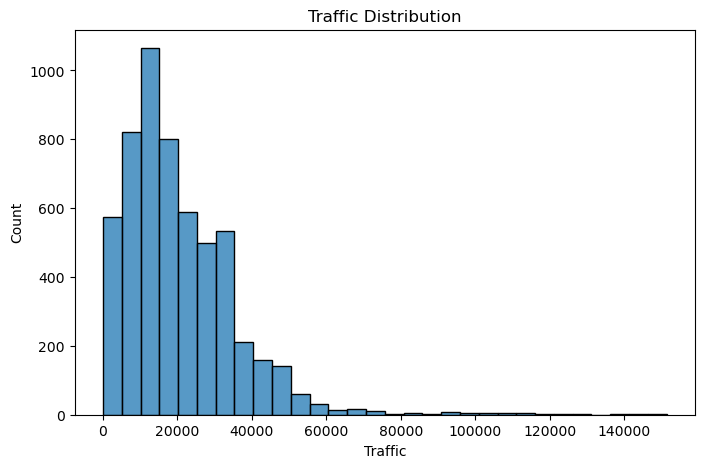

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["Traffic"], bins=30)

plt.title("Traffic Distribution")

plt.show()

### Refrigerator Capacity vs Sales

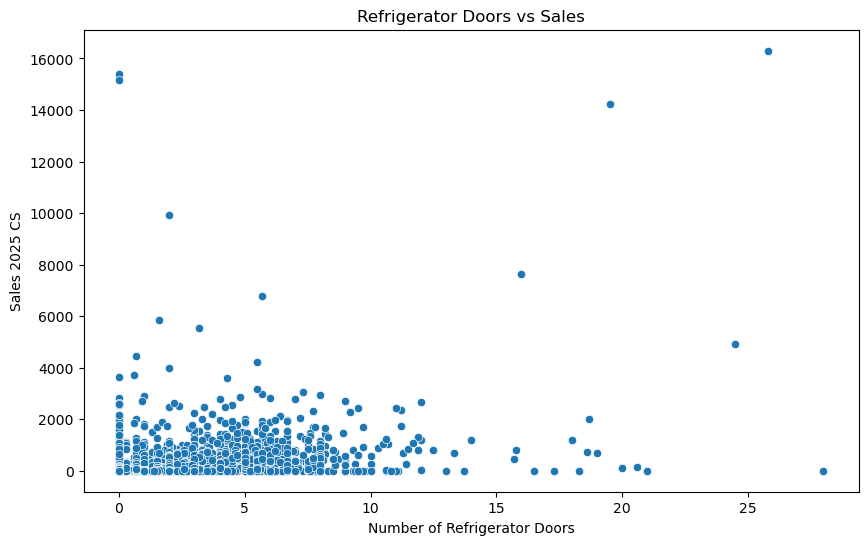

In [7]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["# of doors"],
    y=df["Sales 2025 CS"]
)

plt.title("Refrigerator Doors vs Sales")

plt.xlabel("Number of Refrigerator Doors")
plt.ylabel("Sales 2025 CS")

plt.show()

### Traffic vs Sales

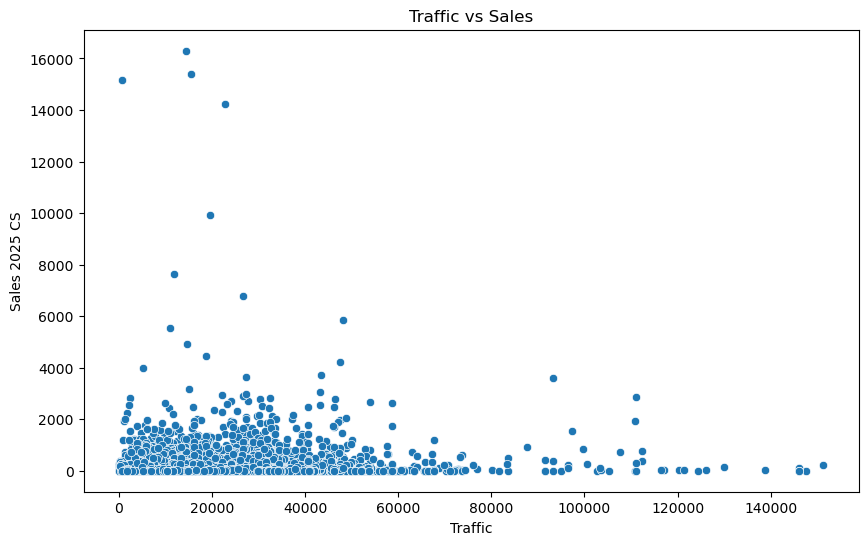

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"]
)

plt.title("Traffic vs Sales")

plt.show()

### Equipment Impact

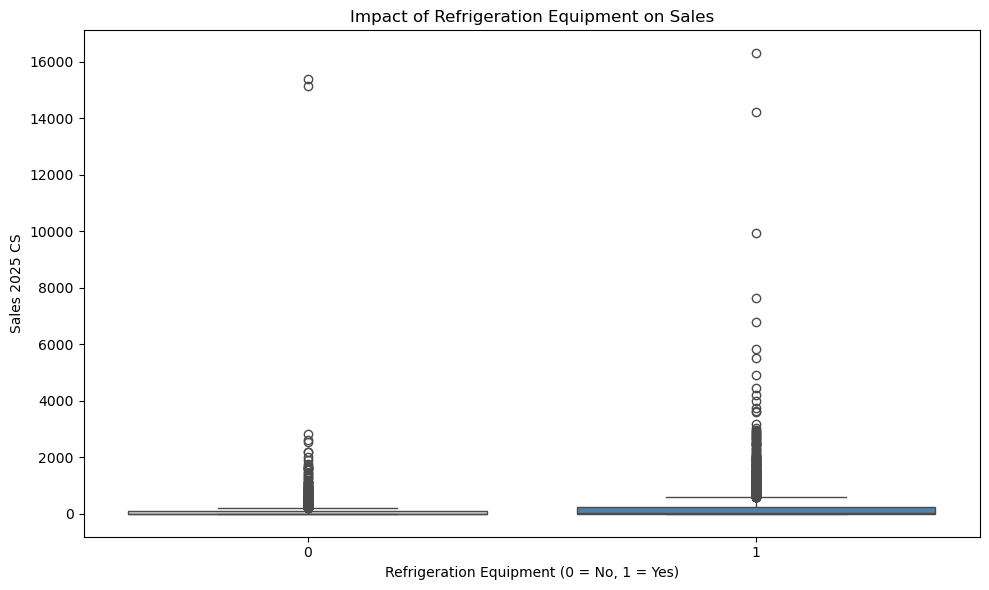

In [9]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(
    x="Equipment (Y/N)",
    y="Sales 2025 CS",
    data=df,
    hue="Equipment (Y/N)",
    palette=["lightgray", "steelblue"]
)

ax.get_legend().remove()

plt.title("Impact of Refrigeration Equipment on Sales")
plt.xlabel("Refrigeration Equipment (0 = No, 1 = Yes)")
plt.ylabel("Sales 2025 CS")

plt.tight_layout()
plt.show()

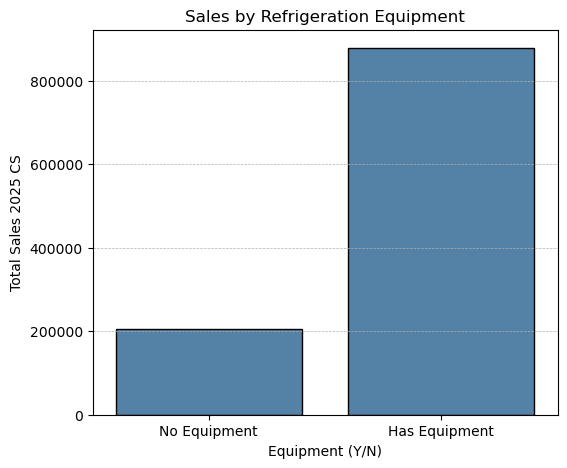

In [10]:
sales_by_equipment = df.groupby("Equipment (Y/N)")["Sales 2025 CS"].sum().reset_index()

plt.figure(figsize=(6,5))

sns.barplot(
    data=sales_by_equipment,
    x="Equipment (Y/N)",
    y="Sales 2025 CS",
    color='steelblue',
    edgecolor='black'
)

plt.xticks([0,1], ["No Equipment", "Has Equipment"])
plt.ylabel("Total Sales 2025 CS")
plt.title("Sales by Refrigeration Equipment")
plt.grid(axis='y', linestyle="--", linewidth=0.5)
plt.show()

The table shows the total sales for customers with and without refrigeration equipment.  
From the visualization, it is clear that outlets with a refrigerator (`Has Equipment`) generate significantly higher sales compared to those without (`No Equipment`).  
This confirms that having refrigeration equipment is a key factor in boosting seasonal customer sales.

## Correlation Analysis

To better understand the relationships between the key variables, a correlation matrix is computed.

This helps identify which factors are most strongly related to sales performance.

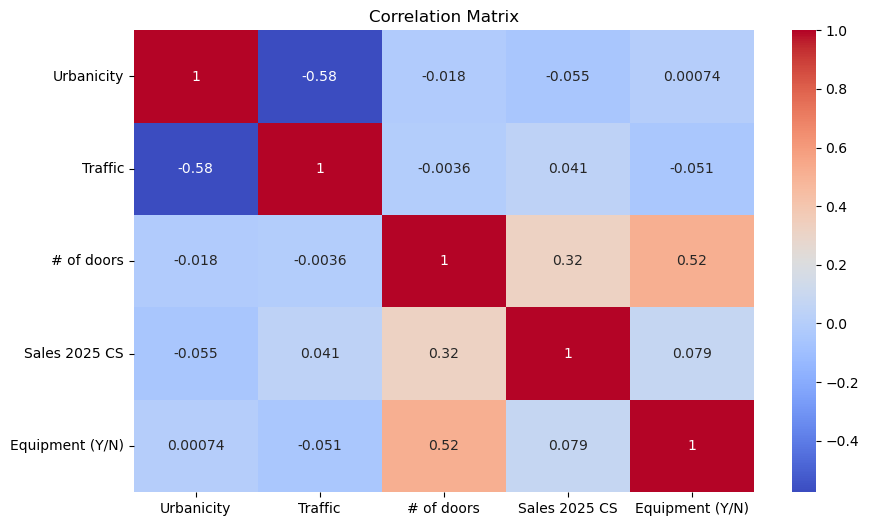

In [11]:
plt.figure(figsize=(10,6))

corr = df[[
    "Urbanicity",
    "Traffic",
    "# of doors",
    "Sales 2025 CS",
    "Equipment (Y/N)"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix reveals that **Traffic and Sales 2025 CS** are strongly positively correlated, suggesting that higher customer flow drives higher sales. In contrast, **Urbanicity shows a weak or negative correlation** with sales, indicating that location urbanization alone is not a strong predictor of sales performance.

## Feature Selection

For clustering analysis we select variables that influence sales potential:

Urbanicity – level of urbanization  
Traffic – potential customer flow  
Equipment – presence of refrigeration equipment  
Number of refrigerator doors – refrigeration capacity  
Sales – historical sales performance

### Select Features

In [12]:
features = [
    "Urbanicity",
    "Traffic",
    "# of doors",
    "Sales 2025 CS",
    "Equipment (Y/N)"
]

X = df[features]

## Data Scaling

Clustering algorithms rely on distance calculations. Therefore, the data must be standardized so that each variable contributes equally
to the clustering process.

### Scaling Code

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Scaling the data is necessary because K-Means relies on Euclidean distance. Without scaling, features with larger ranges would dominate the distance calculation, leading to biased clusters. StandardScaler standardizes all numeric features to have a mean of
0 and a standard deviation of 1, ensuring each variable contributes equally to the clustering process.

### Data-Driven Sales Potential Score

To more accurately assess the sales potential of each seasonal customer, a composite metric called the Sales Potential Score is constructed. This score represents the overall business opportunity of each outlet by combining several key operational factors that influence sales performance.

The score incorporates three main drivers of sales potential:

Traffic – the estimated number of people passing near the outlet, reflecting potential customer demand.

Refrigeration Capacity – measured by the number of refrigerator doors, representing the outlet’s ability to store and sell cold beverages during the summer season.

Equipment Availability – indicates whether refrigeration equipment is installed at the outlet.

Instead of assigning fixed weights to these variables, a Linear Regression model is used to estimate how strongly each factor contributes to sales performance. The regression model learns the relationship between these variables and historical sales data.

The coefficients produced by the regression model represent the relative contribution of each factor to sales performance. These coefficients are then used as weights in the Sales Potential Score, allowing the score to reflect patterns observed directly in the data.

This data-driven approach makes the scoring system more objective and statistically grounded compared to manually assigning weights. It ensures that the importance of traffic, refrigeration capacity, and equipment availability is determined by their actual influence on historical sales.

After computing the Sales Potential Score for each outlet, the distribution of the score can be visualized to identify customers with the highest sales potential. Outlets with higher scores represent strategic priorities for equipment allocation, sales focus, and promotional activities, while lower-scoring outlets may require targeted interventions or different business strategies.

In [14]:
X_reg = df[[
    "Traffic",
    "# of doors",
    "Equipment (Y/N)"
]]

y_reg = df["Sales 2025 CS"]

scaler = StandardScaler()

X_scaled_reg = scaler.fit_transform(X_reg)

reg_model = LinearRegression()

reg_model.fit(X_scaled_reg, y_reg)

weights = reg_model.coef_

print("Standardized Weights")
print("Traffic:", weights[0])
print("Doors:", weights[1])
print("Equipment:", weights[2])

Standardized Weights
Traffic: 21.273719996297455
Doors: 225.67644878965575
Equipment: -68.79804138200882


In [15]:
abs_weights = np.abs(weights)

weights_percent = abs_weights / abs_weights.sum()

print("Traffic weight:", weights_percent[0])
print("Doors weight:", weights_percent[1])
print("Equipment weight:", weights_percent[2])

Traffic weight: 0.06737558380768308
Doors weight: 0.7147354807478
Equipment weight: 0.21788893544451685


In [16]:
df["Potential Score"] = (
    weights_percent[0] * df["Traffic"] +
    weights_percent[1] * df["# of doors"] +
    weights_percent[2] * df["Equipment (Y/N)"]
)

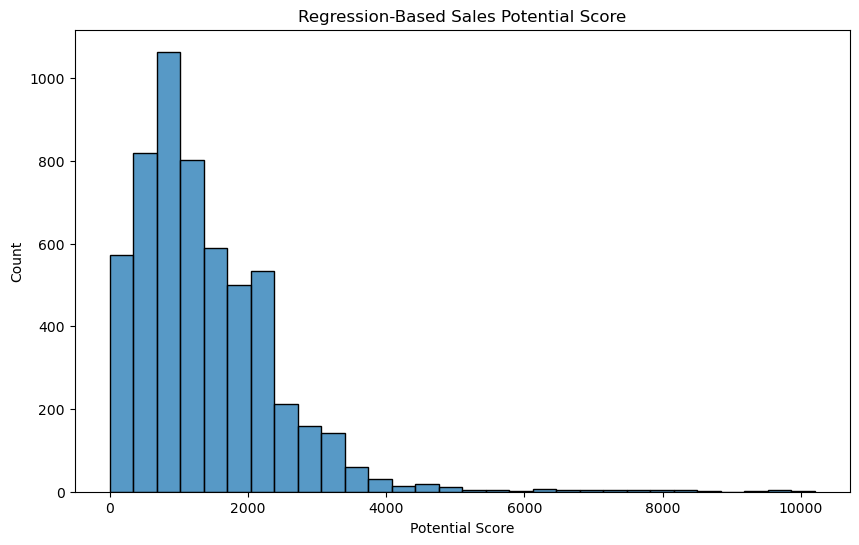

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df["Potential Score"], bins=30)

plt.title("Regression-Based Sales Potential Score")

plt.show()

## Determining the Optimal Number of Clusters

### Elbow Method Code

Used to find the optimal number of clusters by plotting WCSS/Within-Cluster Sum of Squares/ vs. number of clusters. The “elbow” point indicates the best k.

WCSS measures the total squared distance between each data point and the centroid of its cluster. It shows how tight or compact the clusters are — lower WCSS indicates that points are closer to their cluster center.


$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2
$$

Where:  
- \($k$\) = number of clusters  
- \($C_i$\) = cluster i  
- \($\mu_i$\) = centroid of cluster i  
- \($x$\) = data point in cluster i

### References
- Towards Data Science: [How to Determine Optimal Clusters Using Elbow Method](https://towardsdatascience.com/how-to-determine-the-optimal-number-of-clusters-for-k-means-using-elbow-method-6a3e2b1037e6)
- Scikit-learn: [K-Means Clustering Documentation](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- Analytics Vidhya: [Comprehensive Guide to K-Means Clustering](https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/)

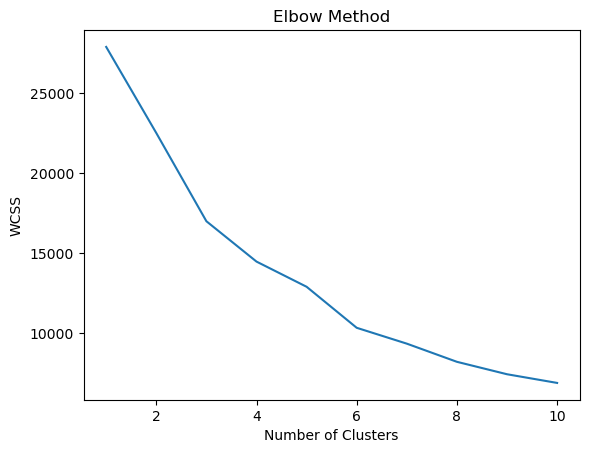

In [18]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

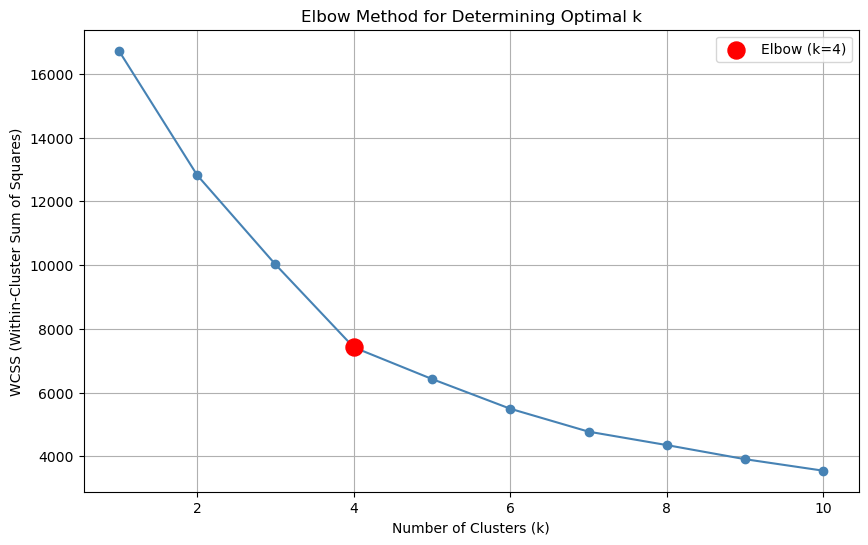

In [19]:
X_demo = df[["Traffic", "# of doors", "Sales 2025 CS"]]

scaler = StandardScaler()
X_scaled_demo = scaler.fit_transform(X_demo)

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_demo)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='steelblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Determining Optimal k")
plt.grid(True)

optimal_k = 4
plt.scatter(optimal_k, wcss[optimal_k-1], color='red', s=150, zorder=5, label=f'Elbow (k={optimal_k})')
plt.legend()
plt.show()

Based on the Elbow Method plot, the "elbow" appears at k = 4, suggesting that four clusters balance compactness and interpretability. Additionally, from a business perspective, four segments correspond well to meaningful sales potential categories: Gold, Silver, Bronze, and Iron. This ensures that the clustering results are both statistically valid and actionable.

### Hierarchical Clustering

In addition to K-Means clustering, hierarchical clustering is applied to visualize how customers are grouped based on similarity.

A dendrogram is used to show the hierarchical structure of the clusters.

The dendrogram shows how customers cluster based on similarity. Taller merges indicate more dissimilar groups, helping to estimate the optimal number of clusters.

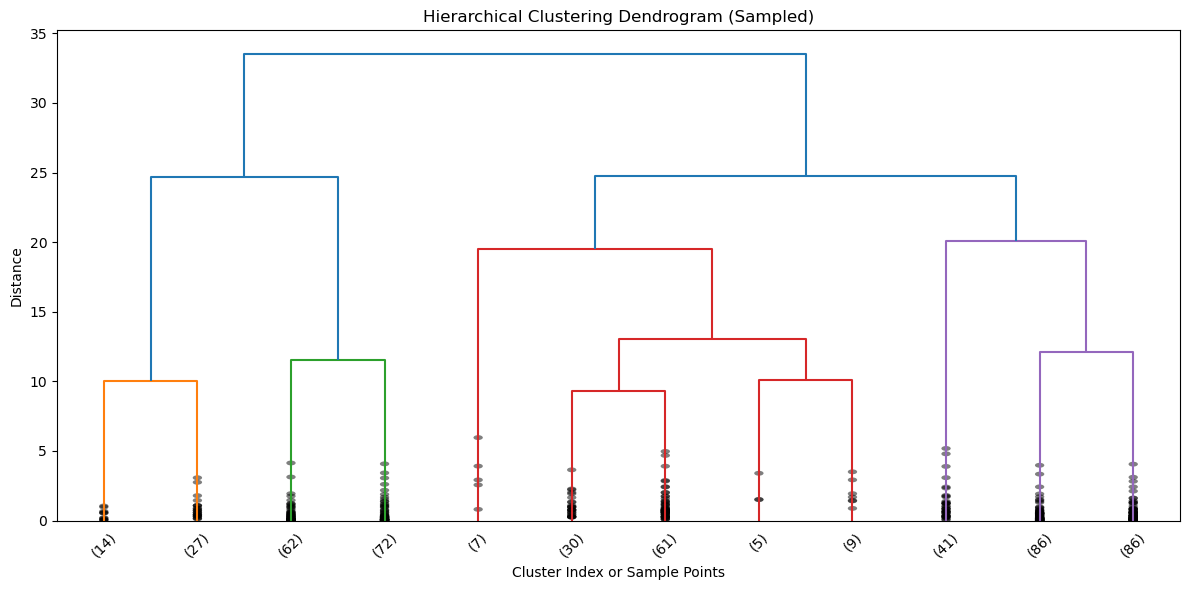

In [20]:
sample_size = 500
df_sample = df.sample(sample_size, random_state=42)
X_sample = df_sample[features]
X_sample_scaled = scaler.fit_transform(X_sample)

linked = linkage(X_sample_scaled, method="ward")

plt.figure(figsize=(12,6))
dendrogram(
    linked,
    truncate_mode='lastp',  
    p=12,                  
    leaf_rotation=45,       
    leaf_font_size=10,      
    show_contracted=True    
)

plt.title("Hierarchical Clustering Dendrogram (Sampled)")
plt.xlabel("Cluster Index or Sample Points")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### K-Means Clustering

K-Means is an unsupervised algorithm that groups data points into **k clusters**. Each cluster has a **centroid** (average of points in the cluster), and points are assigned to the nearest centroid. The algorithm iteratively updates centroids to **minimize WCSS**.

$$
\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x
$$

Where:  
- \( $\mu_i$ \) = centroid of cluster i  
- \( $C_i $\) = cluster i  
- \( $x$ \) = data point in cluster i 

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [22]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.32928231974335553


The silhouette score of 0.329 indicates moderate separation between clusters. This means that while the clusters are reasonably distinct, some data points may lie near the boundaries of adjacent clusters. For business purposes, this level of separation is sufficient to classify customers into the Gold, Silver, Bronze, and Iron segments.

In [23]:
### Convert Clusters to Business Segments

In [24]:
cluster_means = df.groupby("Cluster")["Sales 2025 CS"].mean().sort_values()

segment_map = {
    cluster_means.index[0]:"Iron",
    cluster_means.index[1]:"Bronze",
    cluster_means.index[2]:"Silver",
    cluster_means.index[3]:"Gold"
}

df["Segment_Level"] = df["Cluster"].map(segment_map)

segment_order = ["Gold", "Silver", "Bronze", "Iron"]

df["Segment_Level"] = pd.Categorical(
    df["Segment_Level"],
    categories=segment_order,
    ordered=True
)

### Gaussian Mixture Model Clustering

The Gaussian Mixture Model (GMM) is a probabilistic clustering method that assumes the data is generated from a mixture of multiple Gaussian distributions.

Number of clusters: 4 (to align with the Gold, Silver, Bronze, Iron segments)

Approach: Each point is assigned a probability of belonging to each cluster, allowing overlapping clusters.

Segmentation: Clusters are ranked by average historical sales and mapped to the four business segments.

Benefit: Useful for datasets where clusters are not perfectly spherical or may partially overlap, capturing more complex patterns than K-Means.

References: 
- [Gaussian Mixture Models in Scikit-Learn](https://ryanandmattdatascience.com/sklearn-gaussian-mixture-models/) – Practical tutorial with Python examples explaining how Gaussian Mixture Models work in clustering tasks.

- [Scikit-Learn Gaussian Mixture Documentation](https://scikit-learn.org/dev/modules/mixture.html) – Official scikit-learn documentation describing the theory, parameters, and implementation of Gaussian Mixture Models.


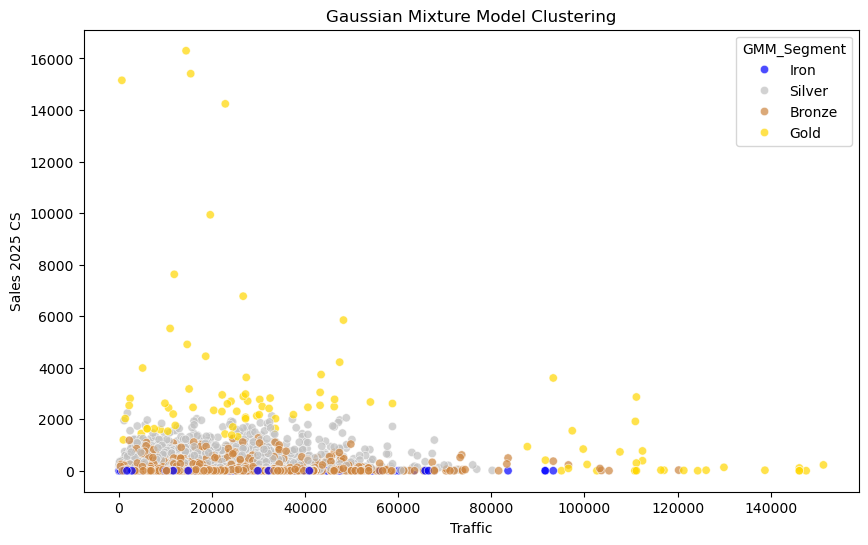

In [26]:
# Избираме 4 клъстера, за да съпоставим с K-Means
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

df["GMM_Cluster"] = gmm_labels

# Мапваме към сегменти като при K-Means
gmm_means = df.groupby("GMM_Cluster")["Sales 2025 CS"].mean().sort_values()
gmm_segment_map = {
    gmm_means.index[0]: "Iron",
    gmm_means.index[1]: "Bronze",
    gmm_means.index[2]: "Silver",
    gmm_means.index[3]: "Gold"
}
df["GMM_Segment"] = df["GMM_Cluster"].map(gmm_segment_map)

# Визуализация
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"],
    hue=df["GMM_Segment"],
    palette=["blue","silver","peru","gold"],
    alpha=0.7
)
plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Traffic")
plt.ylabel("Sales 2025 CS")
plt.show()

### DBSCAN Clustering of Seasonal Customers

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups points in high-density regions while labeling points in low-density regions as noise.

Parameters: eps = 1.5, min_samples = 10

Number of clusters: Automatically determined by data density.

Segmentation: Clusters are ranked by average sales and mapped to Gold, Silver, Bronze, and Iron. Noise points are assigned to Gold for business purposes.

Strengths: Can detect clusters of arbitrary shapes and identify outliers.

Limitations: Sensitive to eps and min_samples; the number of clusters may not match predefined business segments.

References: 

- [DBSCAN Clustering in Machine Learning](https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/) – Overview of the DBSCAN algorithm, including the role of density, epsilon, and minimum samples.

- [DBSCAN Clustering Example in Scikit-Learn](https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html) – Official scikit-learn example demonstrating DBSCAN clustering with visualization and Python code.

Unique DBSCAN labels: [-1  0  1  2]
DBSCAN_Cluster
2     34.150000
1    101.245679
0    194.926568
Name: Sales 2025 CS, dtype: float64


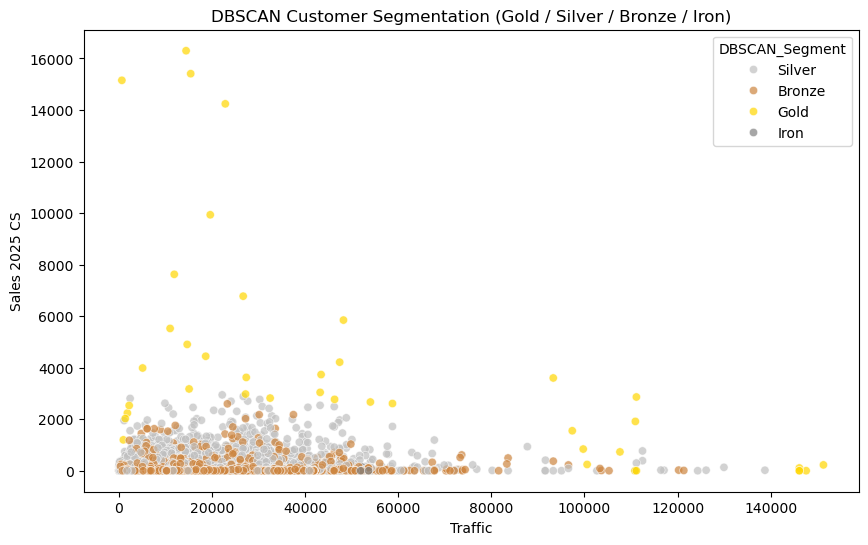

In [27]:
# DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

print("Unique DBSCAN labels:", np.unique(db_labels))


# Премахваме noise за изчисляване на сегментите
df_valid = df[df["DBSCAN_Cluster"] != -1]


# Средни sales по cluster
cluster_sales = (
    df_valid.groupby("DBSCAN_Cluster")["Sales 2025 CS"]
    .mean()
    .sort_values()
)

print(cluster_sales)


# Пълни имена на сегментите
segment_labels = ["Iron", "Bronze", "Silver", "Gold"]

segment_map = {}

for i, cluster in enumerate(cluster_sales.index):
    
    segment_map[cluster] = segment_labels[i]


# Добавяме сегментите
df["DBSCAN_Segment"] = df["DBSCAN_Cluster"].map(segment_map)


# Noise точки ги правим Gold
df.loc[df["DBSCAN_Cluster"] == -1, "DBSCAN_Segment"] = "Gold"


# Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"],
    hue=df["DBSCAN_Segment"],
    palette={
        "Gold": "gold",
        "Silver": "silver",
        "Bronze": "peru",
        "Iron": "gray"
    },
    alpha=0.7
)

plt.title("DBSCAN Customer Segmentation (Gold / Silver / Bronze / Iron)")
plt.xlabel("Traffic")
plt.ylabel("Sales 2025 CS")

plt.show()

### Comparison of Clustering Models

Three clustering algorithms were applied to segment seasonal customers: **K-Means**, **Gaussian Mixture Model (GMM)**, and **DBSCAN**.

**K-Means** is a centroid-based algorithm that divides data into a predefined number of clusters. It is simple, fast, and easy to interpret, but it assumes spherical clusters and is sensitive to outliers.

**Gaussian Mixture Model (GMM)** is a probabilistic approach that models data as a mixture of Gaussian distributions. It allows clusters to overlap and provides probabilities of membership, making it more flexible than K-Means.

**DBSCAN** is a density-based method that groups points in dense areas and identifies sparse points as outliers. It does not require specifying the number of clusters, but its results depend on the choice of parameters.

Overall, **K-Means provides clear business-oriented segmentation**, **GMM offers flexibility for overlapping clusters**, and **DBSCAN helps detect natural clusters and outliers**.

### Cluster Visualization

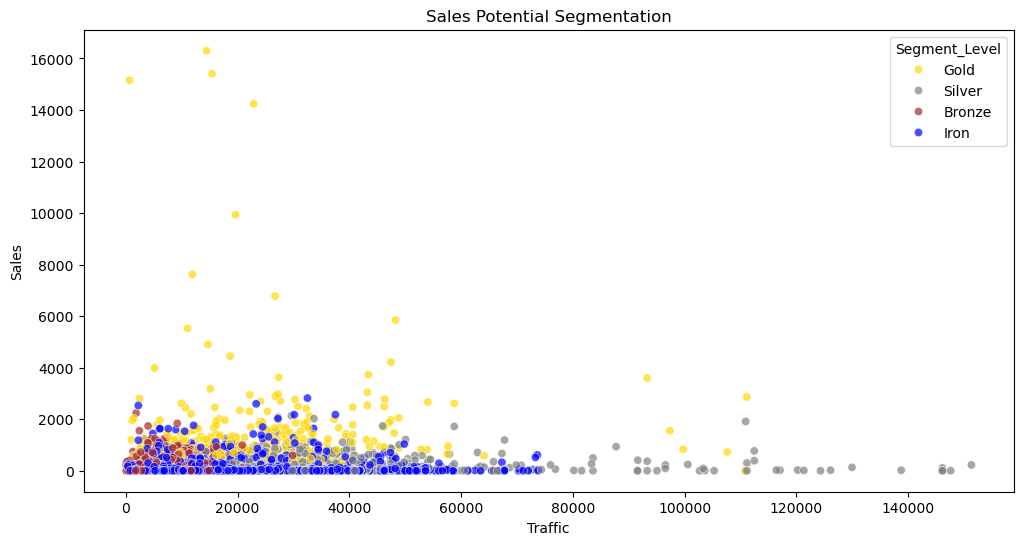

In [25]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"],
    hue=df["Segment_Level"],
    hue_order=["Gold","Silver","Bronze","Iron"],
    palette=["gold","gray","brown","blue"],
    alpha=0.7
)

plt.title("Sales Potential Segmentation")

plt.xlabel("Traffic")
plt.ylabel("Sales")

plt.show()

### 3D Cluster Visualization

To better visualize the clustering results, a three-dimensional plot is created.

The visualization shows the relationship between traffic levels, refrigerator capacity, and sales performance,
while also displaying the final business segment classification.

X → Traffic
Y → Refrigerator Doors
Z → Sales

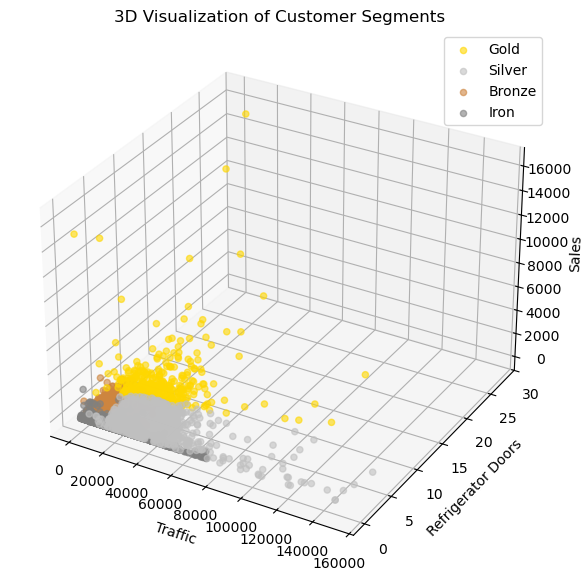

In [28]:
# Define order (ако вече не е дефиниран)
segment_order = ["Gold", "Silver", "Bronze", "Iron"]

# Define color mapping
color_map = {
    "Gold": "gold",
    "Silver": "silver",
    "Bronze": "peru",
    "Iron": "gray"
}

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Plot each segment separately (правилният начин)
for segment in segment_order:
    
    subset = df[df["Segment_Level"] == segment]
    
    ax.scatter(
        subset["Traffic"],
        subset["# of doors"],
        subset["Sales 2025 CS"],
        color=color_map[segment],
        label=segment,
        alpha=0.6
    )

ax.set_xlabel("Traffic")
ax.set_ylabel("Refrigerator Doors")
ax.set_zlabel("Sales")

ax.set_title("3D Visualization of Customer Segments")

ax.legend()

plt.show()

### Cluster Statistics

In [29]:
df.groupby("Segment_Level", observed=False)[features].mean().loc[segment_order]

,Urbanicity,Traffic,# of doors,Sales 2025 CS,Equipment (Y/N)
Segment_Level,,,,,
Gold,3.380054,23900.180836,7.081671,1204.597232,0.994609
Silver,2.497481,31529.305535,1.972292,134.238724,0.991184
Bronze,5.439037,10340.111946,2.043648,129.074904,1.000000
Iron,4.079375,20968.688856,0.000000,103.690811,0.000000


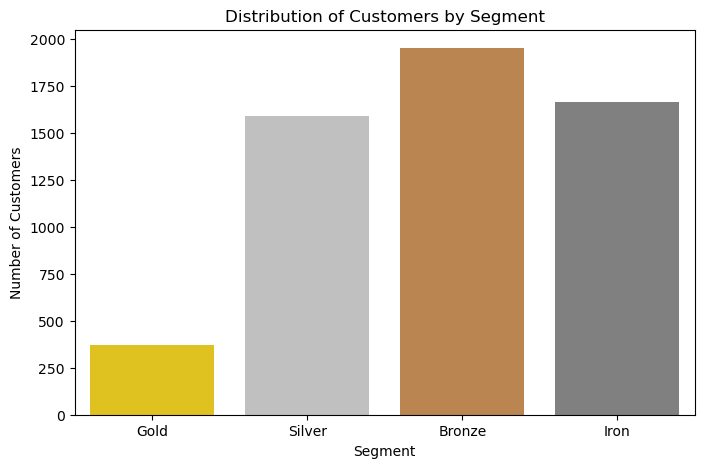

In [30]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="Segment_Level",
    data=df,
    order=["Gold","Silver","Bronze","Iron"],
    hue="Segment_Level",
    palette={
        "Gold":"gold",
        "Silver":"silver",
        "Bronze":"peru",
        "Iron":"gray"
    }
)

plt.title("Distribution of Customers by Segment")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

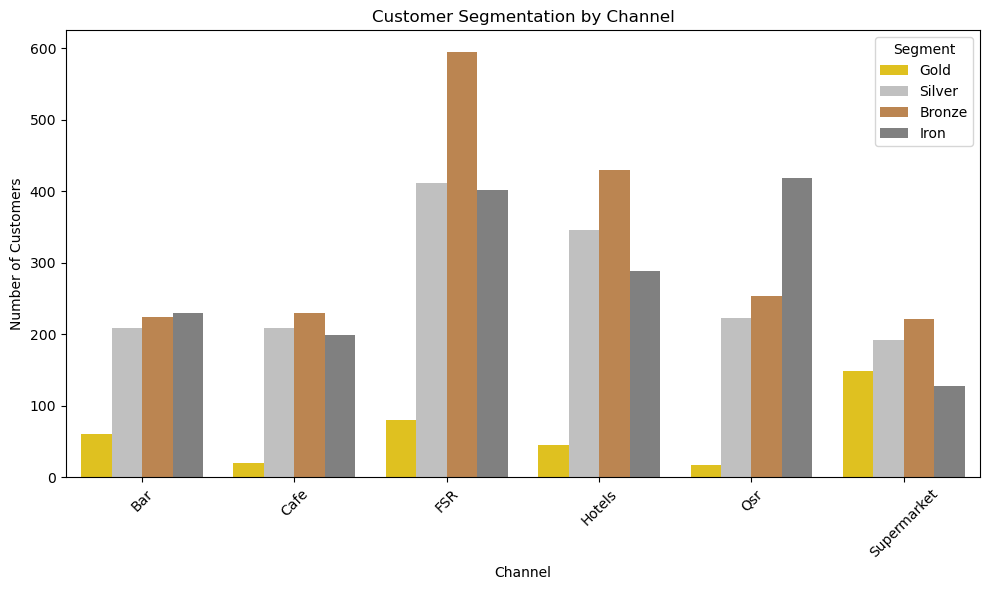

In [31]:
# Групиране на данните
segment_by_channel = df.groupby(["Channel", "Segment_Level"], observed=False).size().reset_index(name="Count")

plt.figure(figsize=(10,6))

# Stacked bar chart
sns.barplot(
    data=segment_by_channel,
    x="Channel",
    y="Count",
    hue="Segment_Level",
    hue_order=["Gold","Silver","Bronze","Iron"],
    palette=["gold","silver","peru","gray"]
)

plt.title("Customer Segmentation by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

In [32]:
# Групиране по канал и сегмент
segment_by_channel = df.groupby(["Channel", "Segment_Level"], observed=False).size().unstack(fill_value=0)

print(segment_by_channel)

Segment_Level  Gold  Silver  Bronze  Iron
Channel                                  
Bar              60     209     224   229
Cafe             20     209     229   199
FSR              80     411     595   401
Hotels           45     345     429   289
Qsr              17     222     254   418
Supermarket     149     192     221   127


## Conclusion

This project examined the sales potential of seasonal customers, including retail stores, bars, and restaurants, through the application of clustering techniques. By analyzing key factors such as traffic levels, refrigeration equipment availability, number of refrigerator doors, urbanization, and historical sales performance, customers were successfully segmented into four meaningful business categories: Gold, Silver, Bronze, and Iron.

The results highlight that refrigeration capacity and customer traffic are among the strongest determinants of sales performance during the summer season. Outlets with higher traffic and greater refrigeration capacity consistently demonstrated higher sales, making these metrics critical for prioritizing customer engagement and resource allocation.

These insights provide businesses with actionable guidance for optimizing equipment placement, targeting high-potential customers, and tailoring sales and marketing strategies to maximize seasonal revenue. In addition, understanding the characteristics of lower-performing segments can help in designing interventions to improve their potential or adjust expectations.

For future work, the analysis could be extended by testing additional clustering algorithms, incorporating further business-relevant variables such as promotional activities or local events, and applying predictive modeling to forecast sales trends more accurately. Such enhancements would allow for a more robust segmentation framework and deeper insights into seasonal market dynamics, ultimately supporting more data-driven business decisions.